# **Setup**

---

We are going to use **TESS_CUTOUT** to do photometry on a star found by using coordinates.

We will use the TESS cutout feature to get pixels around the wanted star and do our own photometry on it.

Here we will install the important packages and import necessary modules and modify matplotlib graph parameters so they dont clutter the output much later on.

A very important link is to the **documentation on lightkurve**: https://lightkurve.github.io/lightkurve/reference/search.html

We will also create a class to use later on to store all of the information on the given lightcurves. And we will also define a function to do the photometry

In [ ]:
!pip install lightkurve
from astropy import table
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import SkyCoord
import os
from google.colab import files
from google.colab import output
from IPython.display import display
import lightkurve as lk
from lightkurve import periodogram
import shutil
from astropy.time import Time
plt.rcParams.update({
        "axes.titlesize": 2,      # Subplot title size
        "xtick.labelsize": 6,     # X-axis tick label size (horizontal colorbar)
        "ytick.labelsize": 6,     # Y-axis tick label size (vertical colorbar)
        "legend.fontsize": 2,     # Legend font size
        "axes.labelsize": 6,      # Axis label & colorbar label size
        "figure.titlesize": 8,    # Main figure title size
        "figure.subplot.right": 1.2
})
class observation:
    def __init__(self, lightcurve):
            self.lc = lightcurve #lc object attribute
            self.normlc = lightcurve.normalize() #normalized lc
            #self.pg = lk.periodogram.LombScarglePeriodogram.from_lightcurve(self.normlc,minimum_period = minimum_period, maximum_period= maximum_period, oversample_factor = oversample_factor) #creates periodogram from normalized lc
            #self.period = self.pg.period_at_max_power #most likely period
            self.flatlc = lightcurve.flatten() #flattened lc
            #self.flatpg = lk.periodogram.LombScarglePeriodogram.from_lightcurve(self.flatlc,minimum_period = minimum_period, maximum_period= maximum_period, oversample_factor = oversample_factor) #creates periodogram from flattened lc
            #self.flatperiod = self.flatpg.period_at_max_power #most likely period of flattened lc
            #self.boxpg = lk.periodogram.BoxLeastSquaresPeriodogram.from_lightcurve(self.normlc,minimum_period = minimum_period, maximum_period= maximum_period) #creates periodogram from normalized lc
            #self.boxperiod = self.boxpg.period_at_max_power #most likely period of box lc
            #self.flatboxpg = lk.periodogram.BoxLeastSquaresPeriodogram.from_lightcurve(self.flatlc,minimum_period = minimum_period, maximum_period= maximum_period) #creates periodogram from flattened lc
            #self.flatboxperiod = self.flatboxpg.period_at_max_power #most likely period of flattened lc
            self.periodogram = None
            self.period = None
            self.mask_type = None
            self.mask_characteristic = None
            self.was_split = False
            self.periodogram_type = None
            self.detrended_lc = None

output.clear()

The next cell defines the important parameters for the photometry



In [ ]:
cutout_size_global = 20 #A target pixel file with the dimensions cutout_size x cutout_size will be selected around the star.
quality_bitmask = "hard" #defines what quality of pixel do we want to allow, possible values include: none, default, hard, hardest (more info in the documentation of lightkurve)
threshold_star = 30 # A value for the number of sigma by which a pixel needs to be brighter than the median flux to be included in the aperture mask.
threshold_bg = 0.0001 #threshold value for the definiton of what background is and what isnt. the higher the values the more will be considered bg
threshold_include_global = 1000 #threshold of flux required to include the given lightcurve into the final list
minimum_period = 4 #minimum period when searching for periods inside the lightcurves (guess from SIPS)
maximum_period = 10 #maximum period when searching for periods inside the lightcurves (guess from SIPS)
oversample_factor = 10 #in documentation to lightkurve
include_center_pixel = False # decide whteher you want to include the reference pixel in the star mask
mask_radius_global = 1 # if using the aperture mask around a pixel, this is the radius that will be used
mask_size_global = 3 # if using a box aperture around a star, this will be the size

In [ ]:
tpfs = None
tpf = None
cat_name = None
your_name = None
coord = None
search_results = None
dec = None
ra = None
obs = None
observations = None
main_lc = None
main_periodogram = None
flat_main_lc = None
flat_main_periodogram = None
observations_backup = None
photometry = None
search_results_backup = None
split_lc = None
tpfs_single = None
split_periods = None
split_weights = None
eclipse_time = None



---

# **Functions**

The next cell defines a function, that creates a circular aperture around a certain pixel (e.g. suspected variable star)

You may run this while folded, it will define all of the necessary functions.

In [ ]:
def create_circular_mask(cutout_size, mask_radius, reference_pixel):
  """Creates a star mask with a circular aperture.

  Args:
    cutout_size: The size of the cutout in pixels.
    mask_radius: The radius of the circular aperture in pixels.
    reference_pixel: The pixel around which the circular aperture is centered.
      If "center", it is centered around the middle pixel.

  Returns:
    A 2D numpy array representing the star mask.
  """

  star_mask = np.zeros((cutout_size, cutout_size))

  if reference_pixel == "center":
    center_row = cutout_size // 2
    center_col = cutout_size // 2
  else:
    center_row, center_col = reference_pixel

  for row in range(cutout_size):
    for col in range(cutout_size):
      distance = np.sqrt((row - center_row)**2 + (col - center_col)**2)
      if distance <= mask_radius:
        star_mask[row, col] = 1

  return star_mask

The next cell defines a function, that creates a square aperture around a certain pixel (e.g. suspected variable star)

In [ ]:
def create_square_mask(cutout_size, mask_size, reference_pixel):
  """Creates a star mask with a square aperture.

  Args:
    cutout_size: The size of the cutout in pixels.
    mask_size: The size of the square aperture in pixels.
    reference_pixel: The pixel around which the square aperture is centered.
      If "center", it is centered around the middle pixel.

  Returns:
    A 2D numpy array representing the star mask.
  """

  star_mask = np.zeros((cutout_size, cutout_size))

  if reference_pixel == "center":
    center_row = cutout_size // 2
    center_col = cutout_size // 2
  else:
    center_row, center_col = reference_pixel

  # Define the top-left and bottom-right corners of the square aperture
  row_start = max(0, center_row - mask_size // 2)
  row_end = min(cutout_size, center_row + mask_size // 2 + (mask_size % 2))  # Ensure even size is handled correctly
  col_start = max(0, center_col - mask_size // 2)
  col_end = min(cutout_size, center_col + mask_size // 2 + (mask_size % 2))

  # Set the pixels within the square aperture to 1
  star_mask[row_start:row_end, col_start:col_end] = 1

  return star_mask


The next cell defines a photometry functions, that we will use later

In [ ]:
def photometry_func(tpf, mask_radius = mask_radius_global, mask_size = mask_size_global, cutout_size = cutout_size_global, threshold_include = threshold_include_global, mask_type = None, reference_pixel = None):
  """
  Will prompt the user, which type of mask to use for each sector and will allow the user to set a different reference pixel. Will plot the process for each sector and will create the lightcurves.

  Args:
    tpf: A TargetPixelFile object.
    mask_radius: The radius of the circular aperture in pixels.
    mask_size: The size of the square aperture in pixels.
    cutout_size: The size of the cutout in pixels.
    thresh_include: The amount of average flux the star needs to give off to include the light curve.
    *mask_type: Set the type of mask, so you dont get propted for each sector.
    *reference_pixel: You may set this as a tuple or "center" to not get propted for each sector.
  """
  if not mask_type in [0,1,2]:
    mask_type = input("What type of mask do you want to use for sector " + str(tpf.sector) +"?\n 0 - star mask\n 1 - circular aperture\n 2 - square mask \n") #lets user choose ask type
    mask_type = int(mask_type)

  if not reference_pixel:
    if input("Do you want to use a different reference pixel than the center for sector " + str(tpf.sector) +"? (y/n)") == "y":
      reference_pixel = (int(input("y coordinate of the reference pixel for sector " + str(tpf.sector) + ": ")),int(input("x coordinate of the reference pixel for sector " + str(tpf.sector) + ": ")))
    else :
      reference_pixel = "center"
#Creates star mask and prepares mask_characteristic for later
  if mask_type == 0:
    star_mask=tpf.create_threshold_mask(threshold=threshold_star, reference_pixel= reference_pixel) #creates a star mask based on the threshold set
    mask_characteristic = threshold_star
    if reference_pixel == "center" and include_center_pixel: #if we want to include the reference pixel and it is the global one
      star_mask [10:11,10:11] = 1
    elif include_center_pixel and reference_pixel != "center":#if we want to include the reference pixel and it is different that the global one
      star_mask [reference_pixel[0]:reference_pixel[0]+1,reference_pixel[1]:reference_pixel[1]+1] = 1

  elif mask_type == 1:
    star_mask = create_circular_mask(cutout_size, mask_radius, reference_pixel)
    mask_characteristic = mask_radius

  elif mask_type == 2:
    star_mask = create_square_mask(cutout_size, mask_size, reference_pixel)
    mask_characteristic = mask_size

  output.clear()

  fig, axes = plt.subplots(1, 4, figsize=(20, 4))#sets up multiple graphs in a single output

  tpf.plot(ax=axes[0], title="Original TPF in sector " + str(tpf.sector)) #plots the original cutout

  tpf.plot(aperture_mask = star_mask, mask_color = "r", ax=axes[1], title="Target mask") #plots the cutout with the star mask shown
  n_target_pixels = star_mask.sum() #counts the approximate number of pixels the star has
  star_lc = tpf.to_lightcurve(aperture_mask = star_mask) # creates a lightkurve lightcurve for the given star

  bg_mask=~tpf.create_threshold_mask(threshold=threshold_bg, reference_pixel=None) #creates a background mask as an antimask of a mask made with the threshold_bg
  tpf.plot(aperture_mask = bg_mask, mask_color = "w", ax=axes[2], title="Background mask") #plot the bg mask
  n_bg_pixels = bg_mask.sum()#counts the approximate number of pixels the bg has
  bg_lc_per_pixel = tpf.to_lightcurve(aperture_mask=bg_mask)/n_bg_pixels #devides the background signal by the number of pixels the bg has to extablish a bg signal per pixel
  bg_estimate_lc = bg_lc_per_pixel * n_target_pixels #approximate extra signal in the final lightcurve added by the bg

  corr_lc = star_lc - bg_estimate_lc.flux #correcion of the lightcurve
  corr_lc.plot(ax=axes[3]) #plots corrected lightcurve

  #Sets up the observation, we want to return
  obs = observation(corr_lc)
  obs.mask_type = mask_type
  obs.mask_characteristic = mask_characteristic

  average_flux = float(str(np.nanmean(corr_lc.flux)).split(" ")[0]) #computes the average flux of the given lightcurve as a float


  if average_flux > threshold_include: # if there is reasonable flux, the lightcurve and periodorgam is appended to a collection
    return obs, True

  else:
    return obs, False



Will print and save the LombScragle periodograms of the given observations.

In [ ]:
def print_and_save_norm_LS_periodograms(observations, pg_type = "ls"):
  """Plots the periodograms of the given observations normalized lc. Then saves the image

  Args:
    observations: A list of observation objects.
  """
  if len(observations) > 1:
    for obs in observations:
      fig, axes = plt.subplots(1, 1, figsize=(5, 4)) #set up for to show the periodorgams next to each other
      obs.periodogram.plot(ax=axes, title = "Sector " + str(obs.lc.sector)) #plots the periodograms for each sector
      print("The observation from sector "+ str(obs.lc.sector) + " has a period determined by the LS method of " + str(obs.period)) #prints most likely period for each sector
      plt.savefig(create_sector_folder_path(str(obs.lc.sector),your_name +"_sector_"+ str(obs.lc.sector)+ "_periodogram", ".png"), bbox_inches='tight')
      plt.show()
  elif len(observations) == 1:
    observations[0].periodogram.plot(ax=axes, title = "Sector " + str(observations[0].lc.sector))
    plt.savefig(create_sector_folder_path(str(obs.lc.sector),your_name +"_sector_"+ str(obs.lc.sector)+ "_periodogram", ".png"), bbox_inches='tight')
    plt.show()

  if pg_type == "ls":
    main_periodogram = main_lc.to_periodogram(method = "ls", minimum_period = minimum_period, maximum_period= maximum_period, oversample_factor = oversample_factor) #creates the periodogram of a normalized main lc
    print("The main periodogram has a period determined by the LS method of " + str(main_periodogram.period_at_max_power)) #prints the most likely period

  elif pg_type == "bls":
    main_periodogram = main_lc.to_periodogram(method = "bls", minimum_period = minimum_period, maximum_period= maximum_period) #creates the periodogram of a normalized main lc
    print("The main periodogram has a period determined by the BLS method of " + str(main_periodogram.period_at_max_power)) #prints the most likely period

  fig, axes = plt.subplots(1, 1, figsize=(5, 4))
  main_periodogram.plot(ax = axes, title = "Main periodogram") #plots the periodogram

  plt.savefig(create_path(your_name, "norm_periodogram.png"), bbox_inches='tight') #saves the periodograms

  return main_periodogram


In [ ]:
def print_and_save_flat_LS_periodograms(observations,  pg_type = "ls"):
  """Plots the periodograms of the given observations flattened lc. Then saves the image

  Args:
    observations: A list of observation objects.
  """
  if len(observations) > 1:
    for obs in observations:
      fig, axes = plt.subplots(1, 1, figsize=(5, 4)) #set up for to show the periodorgams next to each other
      obs.periodogram.plot(ax=axes, title = "Sector " + str(obs.lc.sector)) #plots the periodograms for each sector
      print("The observation from sector "+ str(obs.lc.sector) + " has a period determined by the LS method of " + str(obs.period)) #prints most likely period for each sector
      plt.savefig(create_sector_folder_path(str(obs.lc.sector),your_name +"_sector_"+ str(obs.lc.sector)+ "_periodogram_flat", ".png"), bbox_inches='tight')
      plt.show()
  elif len(observations) == 1:
    observations[0].periodogram.plot(ax=axes, title = "Sector " + str(observations[0].lc.sector))
    plt.savefig(create_sector_folder_path(str(obs.lc.sector),your_name +"_sector_"+ str(obs.lc.sector)+ "_periodogram_flat", ".png"), bbox_inches='tight')
    plt.show()

  if pg_type == "ls":
    main_periodogram = flat_main_lc.to_periodogram(method = "ls", minimum_period = minimum_period, maximum_period= maximum_period, oversample_factor = oversample_factor) #creates the periodogram of a normalized main lc
    print("The main periodogram has a period determined by the LS method of " + str(main_periodogram.period_at_max_power)) #prints the most likely period

  elif pg_type == "bls":
    main_periodogram = flat_main_lc.to_periodogram(method = "bls", minimum_period = minimum_period, maximum_period= maximum_period, frequency_factor = 10) #creates the periodogram of a normalized main lc
    print("The main periodogram has a period determined by the BLS method of " + str(main_periodogram.period_at_max_power)) #prints the most likely period

  fig, axes = plt.subplots(1, 1, figsize=(5, 4))
  main_periodogram.plot(ax = axes, title = "Main periodogram") #plots the periodogram

  plt.savefig(create_path(your_name, "_periodogram_flat.png"), bbox_inches='tight') #saves the periodograms

  return main_periodogram

Will exclude some search results

In [ ]:
def exclude_sectors(search_results):
  """ Will prompt the user to exclude some search results

      Args:
      search_results: A search_result object.
  """
  sectors_to_exculde = []
  sectors_to_exculde_input = input("Input all of the sectors you wish to exclude separated by a comma: ")
  sectors_to_exculde = sectors_to_exculde_input.split(",")
  for sector in sectors_to_exculde:
    search_results = search_results[search_results.table['mission'] != "TESS Sector "+sector] # Access sector using table
  return search_results

Will plot the first image of each sector next to each other

In [ ]:
import math
def plot_first_image(tpfs):
  """Plots the first image of all of the given TargetPixelFiles.

  Args:
    tpfs: A list of TargetPixelFile objects.
  """
  if len(tpfs) > 4:
    fig, axes = plt.subplots(2, math.ceil(len(tpfs)/2), figsize=(20, 10))
    i=0
    for tpf in tpfs:
      tpf.plot(ax=axes[i % 2 , math.floor(i/2)], title="Original TPF in sector " + str(tpf.sector)) #plots the original cutout
      i+=1
  elif len(tpfs) == 1:
    fig, axes = plt.subplots(1, 1, figsize=(20, 4))
    tpfs[0].plot(ax=axes, title="Original TPF in sector " + str(tpfs[0].sector))
  else:
    fig, axes = plt.subplots(1, len(tpfs), figsize=(20, 4))
    i=0
    for tpf in tpfs:
      tpf.plot(ax=axes[i], title="Original TPF in sector " + str(tpf.sector)) #plots the original cutout
      i+=1

Will plot the normalized lightcurves and save them as well.

In [ ]:
def plot_normalized_lightcurves(observations):
  """Plots the normalized light curves of the given observations and return the main light curve. And saves the image.

  Args:
    observations: A list of observation objects.
  """
  lc_collection = lk.LightCurveCollection([])
  if len(observations) > 4:
    fig, axes = plt.subplots(2, math.ceil(len(observations)/2), figsize=(math.ceil(len(observations)/2)*5, 10))
    i=0
    for obs in observations:
      axes[i % 2 , math.floor(i/2)].set_title("Sector "+str(obs.lc.sector), {'fontsize': 10})
      obs.normlc.plot(ax=axes[i % 2 , math.floor(i/2)])
      lc_collection.append(obs.lc)
      i+=1
  elif len(observations) == 1:
    fig, axes = plt.subplots(1, 1, figsize=(5, 4))
    axes.set_title("Sector "+str(observations[0].lc.sector), {'fontsize': 10})
    observations[0].normlc.plot(ax=axes)
    lc_collection.append(observations[0].lc)
  else:
    fig, axes = plt.subplots(1, len(tpfs), figsize=(len(observations)*5, 4))
    for obs in observations:
      axes[observations.index(obs)].set_title("Sector "+str(obs.lc.sector), {'fontsize': 10})
      obs.normlc.plot(ax=axes[observations.index(obs)])
      lc_collection.append(obs.lc)

  main_lc = lc_collection.stitch() #creates a single normalized lightcurve from the whole collection(normalized to the median of the lc)
  main_lc.plot()
  return main_lc


Will plot flattened lightcurves and save them as well.

In [ ]:
def plot_flattened_lightcurves(observations):
  """Plots the flattened light curves of the given observations and return the main light curve. And saves the image.

  Args:
    observations: A list of observation objects.
  """
  lc_collection = lk.LightCurveCollection([])
  if len(observations) > 4:
    fig, axes = plt.subplots(2, math.ceil(len(observations)/2), figsize=(20, 10))
    i=0
    for obs in observations:
      obs.flatlc.plot(ax=axes[i % 2 , math.floor(i/2)])
      lc_collection.append(obs.flatlc)
      i+=1
  elif len(observations) == 1:
    fig, axes = plt.subplots(1, 1, figsize=(20, 4))
    observations[0].flatlc.plot(ax=axes)
    lc_collection.append(observations[0].flatlc)
  else:
    fig, axes = plt.subplots(1, len(tpfs), figsize=(20, 4))
    for obs in observations:
      obs.flatlc.plot(ax=axes[observations.index(obs)])
      lc_collection.append(obs.flatlc)

  plt.savefig(create_path(your_name, "_flat_lc.png"), bbox_inches='tight') #saves the image

  flat_main_lc = lc_collection.stitch() #creates a single normalized lightcurve from the whole collection(normalized to the median of the lc)
  flat_main_lc.plot()
  return flat_main_lc


The next cell defines a functions, that calculates the approximate amplitude of the lightcurve. It uses 5, 95 percentile to betteravoid outliers.

In [ ]:
def calculate_amplitude (array):
    """Calculates the amplitude of a given array, using the 5 and 95 percentile to avoid outliers.

    Args:
      array: A numpy array.

    Returns:
      The amplitude of the array.
    """
    flux_max = np.percentile(array, 95)
    flux_min = np.percentile(array, 5)
    amplitude = (flux_max - flux_min) / 2
    return amplitude

The next cell caculates the position, when the normalized light curve crosses 1

In [ ]:
def find_crossing_time(lightcurve, amplitude_multiplier=0.03):
  """
  Finds the time when the lightcurve crosses the 1+amplitude_multiplier*amplitude on the y-scale.

  Args:
    lightcurve: A LightCurve object (e.g., from lightkurve).
    amplitude_multiplier: A float that multiplies amplitude.

  Returns:
    The middle time of the crossing event. Returns None if no crossing is found.
  """
  time = lightcurve.time.value
  flux = lightcurve.flux.value


# Bins the flux and time arrays into 200 values to avoid outliers
  flux_subarray = np.array_split(flux, 200)
  flux_bin = []
  for subarray in flux_subarray:
    flux_bin.append(np.nanmean(subarray))

  time_subarray = np.array_split(time, 200)
  time_bin = []
  for subarray in time_subarray:
    time_bin.append(np.nanmean(subarray))


# calculates the amplitude
  amplitude = calculate_amplitude(flux)

#calculates thresholds
  threshold_upper = 1 + amplitude_multiplier * amplitude
  threshold_lower = 1 - amplitude_multiplier * amplitude

#finds crossing times by scanning when the values are and are not inside the thresholds
  crossing_times = []
  inside_crossing = False

  for i in range(len(flux_bin)):
    if flux_bin[i] < threshold_upper and flux_bin[i]> threshold_lower and not inside_crossing:
      start_time = time_bin[i]
      inside_crossing = True
    elif flux_bin[i] < threshold_lower and inside_crossing:
      end_time = time_bin[i]
      inside_crossing = False
      crossing_times.append((start_time, end_time))

  if not crossing_times:
      return None


  # Calculate middle point of the first crossing event
  start_time, end_time = crossing_times[0]
  middle_time = (start_time + end_time) / 2

  # Determines whether the sine wave goes up or down after the crossing point
  if flux_bin[time_bin.index(end_time)+25] > threshold_upper:
    is_start = True
  else:
    is_start = False

  return middle_time, is_start

The next cell will draw phased lightcurves of different sectors into one graph and plot a sine wave through them.

In [ ]:
def plot_folded_lightcurve_with_sine(observations, user_period = None):
  """Plots folded light curves and a sine wave with the given period.

  Args:
    observations: A list of observation objects.
    main_periodogram: The LombScarglePeriodogram object for the main light curve.
  """

  fig, axes = plt.subplots(1, 1, figsize=(10, 4))

  colors = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet', 'pink', 'brown', 'gray', 'purple', 'cyan', 'magenta', 'lime', 'teal', 'olive', 'maroon', 'navy', 'turquoise']

  if user_period:
    for obs in observations:
      obs.normlc.fold(period=user_period, epoch_time=2, normalize_phase=True).scatter(c=colors[observations.index(obs)], ax=axes, label="Sector "+str(obs.lc.sector))
  else:
    for obs in observations:
        obs.normlc.fold(period=main_periodogram.period_at_max_power, epoch_time=2, normalize_phase=True).scatter(c=colors[observations.index(obs)], ax=axes, label="Sector "+str(obs.lc.sector))


  # Generate x values for the sine wave (phase)
  x_values = np.linspace(-0.5, 0.5, 100)

  # Generate y values for the sine wave (amplitude)
  folded_main_lc = main_lc.fold(period=main_periodogram.period_at_max_power, epoch_time=2, normalize_phase=True)

  amplitude = calculate_amplitude(folded_main_lc.flux)

  middle_time, is_start = find_crossing_time(folded_main_lc)

  if is_start:
    x_offset = middle_time
  else:
    x_offset = middle_time + 0.5


  y_values = 1+ amplitude * np.sin(2 * np.pi * (x_values - x_offset))

  # Plot the sine wave
  axes.plot(x_values, y_values, color='black', linestyle='--')
  axes.set_xlabel('Phase', fontsize = 12)
  axes.set_ylabel('Normalized Flux', fontsize = 12)
  axes.legend(fontsize = 12)
  axes.set_title('Folded Light Curves', fontsize = 15)
  plt.savefig(create_path(your_name, "_phase_diagram.png"), bbox_inches='tight')
  plt.show()


In [ ]:
def plot_folded_lightcurve(observations, user_period = None):
  """Plots folded light curves and a sine wave with the given period.

  Args:
    observations: A list of observation objects.
    main_periodogram: The LombScarglePeriodogram object for the main light curve.
  """

  fig, axes = plt.subplots(1, 1, figsize=(4, 4))

  colors = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet', 'pink', 'brown', 'gray', 'purple', 'cyan', 'magenta', 'lime', 'teal', 'olive', 'maroon', 'navy', 'turquoise']


  if user_period:
    for obs in observations:
      obs.normlc.fold(period=user_period, epoch_time=0, normalize_phase=True).scatter(c=colors[observations.index(obs)], ax=axes, label="Sector "+str(obs.lc.sector))
  else:
    for obs in observations:
      obs.normlc.fold(period=main_periodogram.period_at_max_power, epoch_time=0, normalize_phase=True).scatter(c=colors[observations.index(obs)], ax=axes, label="Sector "+str(obs.lc.sector))



  axes.set_xlabel('Phase', fontsize = 12)
  axes.set_ylabel('Normalized Flux', fontsize = 12)
  axes.legend(fontsize = 12)
  if user_period:
    axes.set_title('Folded Light Curves with period ' + str(round(user_period, 5)) + " d.", fontsize = 15)
  else:
    axes.set_title('Folded Light Curves with period ' + str(round(main_periodogram.period_at_max_power, 5)) + ".", fontsize = 15)
  plt.savefig(create_path(your_name, "_phase_diagram.png"), bbox_inches='tight')
  plt.show()

Lc amending

In [ ]:
def split_lc_in_middle(lc):
  """Will split the lightcurve in half and remove 5% from the side, where the splitting happened.

  Args:
    lc: A lightcurve object.
  """
  length = len(lc["cadenceno"])
  lc1 = lc.truncate(after = length/2-length/20, column = "cadenceno")
  lc2 = lc.truncate(before = length/2+length/20, column = "cadenceno")
  return lc1, lc2


Next function will amend the observations array to remove unwanted sectors.

In [ ]:
def exclude_observations(observations_to_amend):
  """ Will prompt the user to exclude some observations

      Args:
      observations: A list of observation objects.
  """
  sectors_to_exculde = []
  sectors_to_exculde_input = input("Input all of the sectors you wish to exclude separated by a comma: ")
  sectors_to_exculde = sectors_to_exculde_input.split(",")
  for sector in sectors_to_exculde:
    for obs in observations_to_amend:
      if obs.lc.sector == int(sector):
        observations_to_amend.remove(obs)
  return observations_to_amend

In [ ]:
def detrend_lc(lc, degree, part):
  """ Will detrend lightcurve using np polyfit, input lightcurve, youll get a normalized one.


      Args:
        lc - lightcurve object
        degree - degree of the polynomial to fit
  """
  coeffs = np.polyfit(lc.normalize().time.value, lc.normalize().flux.value, deg = degree)
  trend = np.polyval(coeffs, lc.normalize().time.value)
  fig, axes = plt.subplots(1, 1, figsize=(4, 4))
  if part:
    axes.set_title("Light curve in " + str(lc.sector) + " part " + str(part) +"with trend", {'fontsize': 10})
  else:
    axes.set_title("Light curve in " + str(lc.sector) +"with trend", {'fontsize': 10})
  lc.normalize().plot(ax = axes)
  plt.plot(lc.normalize().time.value, trend, color = "red")
  plt.show()
  detrended_lc = lc.normalize() - trend + 1
  return detrended_lc

In [ ]:
def split_and_detrend_observation(observations_list, degree = 2):
  sectors_to_split = []
  sectors_to_split_input = input("Input all of the sectors you wish to split and detrend separated by a comma: ")
  sectors_to_split = sectors_to_split_input.split(",")

  split_obs = []

  for obs in observations_list:
    if str(obs.lc.sector) in sectors_to_split:
      lc1, lc2 = split_lc_in_middle(obs.lc) #splits lc in the middle and removes 5% from each side
      detrended_lc1 = detrend_lc(lc1, degree, "1") #detrends split lcs
      detrended_lc2 = detrend_lc(lc2, degree, "2")

      split_obs.append([detrended_lc1, detrended_lc2])

      #plots split lcs
      fig, axes = plt.subplots(1, 2, figsize=(8, 4))
      axes[0].set_title("Light curve in " + str(obs.lc.sector) + " part 1 detrended", {'fontsize': 10})
      axes[1].set_title("Light curve in " + str(obs.lc.sector) + " part 2 detrended", {'fontsize': 10})
      detrended_lc1.plot(ax=axes[0])
      detrended_lc2.plot(ax=axes[1])

      #saves split lc plots
      plt.savefig(create_sector_folder_path(str(obs.lc.sector),your_name + "_detrended_split_lc_" + str(obs.lc.sector), ".png"), bbox_inches='tight') #saves the detrended lcs
      plt.show()

      #information to be used in text output
      obs.was_split = True

  if len(split_obs) > 0:
    return split_obs
  else:
    print("No sectors were split")
    return None



The next cells define functions to create a folder and a subfolder.

In [ ]:
def create_folder(folder_name):
  """Creates a folder with a given name. If the folder exists, promptsthe user whether to delete its contents"""
  if os.path.exists(folder_name):
    response = input(f"Folder '{folder_name}' already exists. Do you want to delete its contents and create a new one? (y/n): ")
    if response.lower() == 'y':
      try:
        shutil.rmtree(folder_name)
        os.makedirs(folder_name)
        print(f"Folder '{folder_name}' contents deleted and recreated.")
      except OSError as e:
        print(f"Error deleting folder: {e}")
    else:
      print(f"Folder '{folder_name}' was not recreated.")
  else:
    try:
      os.makedirs(folder_name)
      print(f"Folder '{folder_name}' created successfully.")
    except OSError as e:
      print(f"Error creating folder: {e}")


In [ ]:
def create_subfolder(folder_name, subfolder_name):
  """Creates a subfolder in a given folder.

  Args:
    folder_name: The name of the folder.
    subfolder_name: The name of the subfolder.
    """
  current_dir = os.getcwd()
  subfolder_path = os.path.join(current_dir, folder_name, subfolder_name)
  os.makedirs(subfolder_path)
  return subfolder_path

The next cell creates the file path to a given file.

In [ ]:
def create_path(name, extension):
  """Creates a path to a file with a given name and extension.

  Args:
    name: The name of the file.
    extension: The extension of the file.

  Returns:
    The path to the file.
  """
  current_dir = os.getcwd()
  subfolder = your_name
  subfolder_path = os.path.join(current_dir, subfolder)
  file_path = os.path.join(subfolder_path, name + extension)
  return file_path

Will create path to specific sector subfolder .

In [ ]:
def create_sector_folder_path(sector, name, extension):
  """Creates a path to a file with a given name and extension.

  Args:
    name: The name of the file.
    extension: The extension of the file.

  Returns:
    The path to the file.
  """
  current_dir = os.getcwd()
  subfolder = your_name
  sector_folder = "sector_" + str(sector)
  subfolder_path = os.path.join(current_dir, subfolder, sector_folder)
  file_path = os.path.join(subfolder_path, name + extension)
  return file_path

The next cell defines a function, that creates a text file with the information

In [ ]:
def create_files(observations, make_csv):
  """Creates a text file with sector and most likely period data and general star information.
  If make_csv is True, also creates csv files for each sector.

  Args:
    observations: A list of observation objects.
    make_csv: A boolean indicating whether to create CSV files for each sector.
  """
  current_dir = os.getcwd()
  subfolder = your_name
  subfolder_path = os.path.join(current_dir, subfolder)
  file_path = os.path.join(subfolder_path, your_name + "_periods.txt")

  coord_string =SkyCoord(str(observations[0].lc.meta['RA'])+" "+str(observations[0].lc.meta['DEC']), unit = (u.deg, u.deg)).to_string('hmsdms')

#writes the txt file
  with open(file_path, 'w') as f:
    f.write(f"Star Name (user input): {your_name} \n")
    f.write(f"Star Name (catalog): {cat_name} \n")
    f.write(f"Ra, Dec: "+ coord_string + "\n")
    f.write("Sector (#cadences), Most Likely Periods, Periodogram method, Mask used, Mask characteristic\n")
    for obs in observations:
      if obs.was_split:
        if obs.period != None:
          f.write(f"{obs.lc.sector}*({len(obs.lc.flux)}), {round(obs.period,8)}, {obs.periodogram_type}, {mask_type_to_str(obs.mask_type, obs.mask_characteristic)} \n")
        else:
          f.write(f"{obs.lc.sector}({len(obs.lc.flux)}), None, None, {mask_type_to_str(obs.mask_type, obs.mask_characteristic)} \n")

      else:
        if obs.period != None:
          f.write(f"{obs.lc.sector}({len(obs.lc.flux)}), {round(obs.period,8)}, {obs.periodogram_type}, {mask_type_to_str(obs.mask_type, obs.mask_characteristic)} \n")
        else:
          f.write(f"{obs.lc.sector}({len(obs.lc.flux)}), None, None, {mask_type_to_str(obs.mask_type, obs.mask_characteristic)} \n")

    if main_periodogram:
      f.write(f"Main lc, {round(main_periodogram.period_at_max_power, 8)}\n")
    elif split_main_period != None:
      f.write(f"Split Main lc, {round(split_main_period, 8)}\n")
    else:
      f.write(f"Main lc, None\n")
    if input("Did you JUST split the lightcurves?(y/n):") == "n":
      f.write(f"\n Weighted average of periods for all sectors above (before splitting and detrending): " + str(round(weighted_average_period(observations), 8)))

    if split_weights:
      f.write(f"\n Weighted average of periods for all sectors above (after splitting and detrending): " + str(round(np.average(split_periods, weights = split_weights), 8)))
    if eclipse_time:
      f.write(f"\n This star is probably an EB (unless I forgot to clear the variable), Eclipse time: {round(eclipse_time, 8)}")
    f.write("\n \n \n * - Light curve from this sector was split, look in side the respective folder to find further information, like periods etc.")

  #outputs csvs of lightcurves, if the user chooses so
  if make_csv:
    for obs in observations:
      #create_sector_folder_path(str(obs.lc.sector),your_name +"_sector_"+ str(obs.lc.sector)+ "_periodogram", ".png")
      csv_file_path = create_sector_folder_path(str(obs.lc.sector), your_name + "_lc_sector_" + str(obs.lc.sector), ".csv")
      obs.lc.to_csv(csv_file_path)


Useful function for printing txt files.

In [ ]:
def mask_type_to_str(mask_type, mask_characteristic):
  """ returns a string to be used in creating txt files regarding the mask type and its charateristic

  Args:
    mask_type: integer value indicative of the mask type used
    mask_characteristic: parameter characteristic for the mask type
  """
  if mask_type == 0:
    return f"Automatic, threshold = {mask_characteristic}"
  elif mask_type == 1:
    return f"Circular, radius = {mask_characteristic}"
  elif mask_type == 2:
    return f"Square, size = {mask_characteristic}"

additional function

In [ ]:
def to_bool(string):
  """Converts a string to a boolean.

  Args:
    string: The string to convert.

  Returns:
    The boolean value.
  """
  if string == "y":
    return True
  else:
    return False

Will zip and download the given folder.

In [ ]:
def zip_and_download_folder(folder_name):
  """Zips a folder, downloads it."""
  import shutil
  from google.colab import files
  import os

  current_dir = os.getcwd()
  folder_path = os.path.join(current_dir, folder_name)
  shutil.make_archive(folder_name, 'zip', folder_path)
  files.download(folder_name + '.zip')


Will delete the given zip file.

In [ ]:
def delete_zip_file(zip_filename):
  """Deletes a zip file with the given name in the current directory.

  Args:
    zip_filename: The name of the zip file to delete (including the .zip extension).
  """
  try:
    os.remove(zip_filename)
    print(f"Zip file '{zip_filename}' deleted successfully.")
  except FileNotFoundError:
    print(f"Zip file '{zip_filename}' not found.")
  except OSError as e:
    print(f"Error deleting zip file: {e}")


Will plot a single folded lc according to its period.

In [ ]:
def find_period_and_plot_folded_lightcurve_with_sine(lc, index, user_period = None, pg_type = "ls"):
  """Plots folded light curves and a sine wave with the given period.

  Args:
    split_lc: A list of lc that were split.
  """
  if pg_type == "ls":
    periodogram = lc.to_periodogram(method = "ls", minimum_period = minimum_period, maximum_period= maximum_period, oversample_factor = oversample_factor) #creates the periodogram of a normalized main lc
    print("The periodogram for the lc provided has a period determined by the LS method of " + str(periodogram.period_at_max_power)) #prints the most likely period

  elif pg_type == "bls":
    periodogram = lc.to_periodogram(method = "bls", minimum_period = minimum_period, maximum_period= maximum_period, frequency_factor = 10) #creates the periodogram of a normalized main lc
    print("The periodogram for the lc provided has a period determined by the BLS method of " + str(periodogram.period_at_max_power)) #prints the most likely period

  periodogram.plot(title = "Sector " + str(lc.sector)+ " part "+ str(index) +"("+pg_type+")")
  plt.savefig(create_sector_folder_path(str(lc.sector),your_name + "_sector_"+ str(lc.sector)+ "_part_"+ str(index) +"_periodogram", ".png"), bbox_inches='tight')
  plt.show()

  fig, axes = plt.subplots(1, 1, figsize=(20, 4))


  if user_period:
    folded_lc = lc.fold(period=user_period, epoch_time=2, normalize_phase=True)
  else:
    folded_lc = lc.fold(period=periodogram.period_at_max_power, epoch_time=2, normalize_phase=True)

  folded_lc.scatter(c="red", ax=axes, label="Sector " + str(lc.sector)+ " part "+ str(index) +"("+pg_type+")")

  # Generate x values for the sine wave (phase)
  x_values = np.linspace(-0.5, 0.5, 100)

  # Generate y values for the sine wave (amplitude)
  amplitude = calculate_amplitude(folded_lc.flux)

  middle_time, is_start = find_crossing_time(folded_lc)

  if is_start:
    x_offset = middle_time
  else:
    x_offset = middle_time + 0.5


  y_values = 1+ amplitude * np.sin(2 * np.pi * (x_values - x_offset))
  # Plot the sine wave
  axes.plot(x_values, y_values, color='black', linestyle='--')
  axes.set_xlabel('Phase', fontsize = 12)
  axes.set_ylabel('Normalized Flux', fontsize = 12)
  axes.legend(fontsize = 12)
  axes.set_title('Folded Light Curves', fontsize = 15)
  plt.savefig(create_sector_folder_path(str(lc.sector),your_name + "_sector_"+ str(lc.sector)+ "_part_"+ str(index) +"_phase_diagram", ".png"), bbox_inches='tight')
  plt.show()


  with open(create_sector_folder_path(str(lc.sector),your_name + "_sector_"+ str(lc.sector)+ "_part_"+ str(index) +"_period", ".txt"), 'w') as f:
    f.write("Sector (#cadences), Most likely period\n")
    f.write(f"{str(lc.sector)} part {str(index)} ({len(lc.flux)}), ")
    f.write(f"{str(periodogram.period_at_max_power)}") #prints the most likely period

In [ ]:
def find_period_and_plot_folded_lightcurve(lc, index, user_period = None, pg_type = "ls"):
  """Plots folded light curves and a sine wave with the given period.

  Args:
    split_lc: A list of lc that were split.
  """
  if pg_type == "ls":
    periodogram = lc.to_periodogram(method = "ls", minimum_period = minimum_period, maximum_period= maximum_period, oversample_factor = oversample_factor) #creates the periodogram of a normalized main lc
    print("The periodogram for the lc provided has a period determined by the LS method of " + str(periodogram.period_at_max_power)) #prints the most likely period

  elif pg_type == "bls":
    periodogram = lc.to_periodogram(method = "bls", minimum_period = minimum_period, maximum_period= maximum_period, frequency_factor = 10) #creates the periodogram of a normalized main lc
    print("The periodogram for the lc provided has a period determined by the BLS method of " + str(periodogram.period_at_max_power)) #prints the most likely period

  periodogram.plot(title = "Sector " + str(lc.sector)+ " part "+ str(index) +"("+pg_type+")")
  split_periods.append(np.float64(str(periodogram.period_at_max_power).split(" ")[0]))
  plt.savefig(create_sector_folder_path(str(lc.sector),your_name + "_sector_"+ str(lc.sector)+ "_part_"+ str(index) +"_periodogram", ".png"), bbox_inches='tight')
  plt.show()

  fig, axes = plt.subplots(1, 1, figsize=(4, 4))


  if user_period:
    folded_lc = lc.fold(period=user_period, epoch_time=2, normalize_phase=True)
  else:
    folded_lc = lc.fold(period=periodogram.period_at_max_power, epoch_time=2, normalize_phase=True)

  folded_lc.scatter(c="red", ax=axes, label="Sector " + str(lc.sector)+ " part "+ str(index) +"("+pg_type+")")

  axes.set_xlabel('Phase', fontsize = 12)
  axes.set_ylabel('Normalized Flux', fontsize = 12)
  axes.legend(fontsize = 12)
  axes.set_title('Folded Light Curves', fontsize = 15)
  plt.savefig(create_sector_folder_path(str(lc.sector),your_name + "_sector_"+ str(lc.sector)+ "_part_"+ str(index) +"_phase_diagram", ".png"), bbox_inches='tight')
  plt.show()


  with open(create_sector_folder_path(str(lc.sector),your_name + "_sector_"+ str(lc.sector)+ "_part_"+ str(index) +"_period", ".txt"), 'w') as f:
    f.write("Sector (#cadences), Most likely period\n")
    f.write(f"{str(lc.sector)} part {str(index)} ({len(lc.flux)}), ")
    f.write(f"{str(periodogram.period_at_max_power)}") #prints the most likely period

Will create a txt file compatible with SILICUPS

In [ ]:
def create_lc_txt(col1, col2, col3, filepath):
  """Creates a text file with two columns corresponding to two arrays.

  Args:
    col1: The first array of data.
    col2: The second array of data.
    filepath: The path to save the file.
  """
  with open(filepath, 'w') as f:
    f.write("# HJD flux flux_err \n")
    f.write("#JD: heliocentric Unit: flux\n")
    f.write(f"# VAR Name: {your_name} RA: {ra} Dec: {dec} \n" )
    for i in range(len(col1)):
      f.write(f"{col1[i]+2457000} {col2[i]} {col3[i]}\n")


Code to calculate a period as a weighted average of the periods with the weights being the number of observations.

In [ ]:
def weighted_average_period(observs):
  periods = []
  weights = []
  for obs in observs:
    periods.append(np.float64(str(obs.period).split(" ")[0]))
    weights.append(math.sqrt(len(obs.lc.flux)))
  return np.average(periods, weights = weights)


Plotting split lcs into one graph.

In [ ]:
def plot_folded_split_lightcurve(split_lc, user_period = None, pg_type = "ls", user_comment = "", epoch_time = 0, move_phase = 0):
  """Plots folded light curves and a sine wave with the given period or with the period.

  Args:
    split_lc: A list of lc that were split.
  """


  colors = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet', 'pink', 'brown', 'gray', 'purple', 'cyan', 'magenta', 'lime', 'teal', 'olive', 'maroon', 'navy', 'turquoise']

  split_lc_collection = lk.LightCurveCollection([])

  for lc in split_lc:
    for part in lc:
      split_lc_collection.append(part)
  split_main_lc = split_lc_collection.stitch() #creates a single normalized lightcurve from the whole collection(normalized to the median of the lc)

  if user_period:
    fig, axes = plt.subplots(1, 1, figsize=(4, 4))
    for lc in split_lc:
      for part in lc:
        part_lc = part.fold(period=user_period, epoch_time=epoch_time, normalize_phase=True)
        part_lc.time, part_lc.flux = cut_and_move(part_lc.time, part_lc.flux, -0.5 + move_phase)
        part_lc.scatter(c=colors[2*split_lc.index(lc)+lc.index(part)], ax=axes, label="Sector "+str(part.sector) + " part " + str(lc.index(part)))
  else:
    if pg_type == "ls":
      split_main_periodogram = split_main_lc.to_periodogram(method = "ls", minimum_period = minimum_period, maximum_period= maximum_period, oversample_factor = oversample_factor) #creates the periodogram of a normalized main lc
      print("The periodogram for the lc provided has a period determined by the LS method of " + str(split_main_periodogram.period_at_max_power)) #prints the most likely period

    elif pg_type == "bls":
      split_main_periodogram = split_main_lc.to_periodogram(method = "bls", minimum_period = minimum_period, maximum_period= maximum_period, frequency_factor = 20) #creates the periodogram of a normalized main lc
      print("The periodogram for the lc provided has a period determined by the BLS method of " + str(split_main_periodogram.period_at_max_power)) #prints the most likely period
    split_main_periodogram.plot(title = "Main lc ("+pg_type+")")
    plt.savefig(create_path(your_name, "_periodogram_" + pg_type+ ".png"), bbox_inches='tight')
    plt.show()
    fig, axes = plt.subplots(1, 1, figsize=(4, 4))

    for lc in split_lc:
      for part in lc:
        part_lc = part.fold(period=split_main_periodogram.period_at_max_power, epoch_time=epoch_time, normalize_phase=True)
        part_lc.time, part_lc.flux = cut_and_move(part_lc.time, part_lc.flux, -0.5 + move_phase)
        part_lc.scatter(c=colors[2*split_lc.index(lc)+lc.index(part)], ax=axes, label="Sector "+str(part.sector) + " part " + str(lc.index(part)))

    split_main_period = split_main_periodogram.period_at_max_power


  axes.set_xlabel('Phase', fontsize = 10)
  axes.set_ylabel('Normalized Flux', fontsize = 10)
  axes.legend(fontsize = 8)
  plt.xlim(-0.5 + move_phase, 0.5 + move_phase)
  if user_period:
    axes.set_title('Folded Light Curves with period ' + str(round(user_period, 6)) + " d.", fontsize = 12)
  else:
    axes.set_title('Folded Light Curves with period ' + str(round(split_main_periodogram.period_at_max_power, 6)) + ".", fontsize = 15)
  plt.savefig(create_path(your_name, "_phase_diagram_" + user_comment+ ".png"), bbox_inches='tight')
  plt.show()

  return split_main_period


Amplitude normalization function.

In [ ]:
def normalize_amplitude_percentile(lc: lk.LightCurve, target_amplitude: float = 0.02, lower_percentile: float = 5, upper_percentile: float = 95) -> lk.LightCurve:
    """
    Normalize the amplitude of a LightCurve using a percentile-based range.

    Parameters:
    ----------
    lc : LightCurve
        The input LightCurve object.
    target_amplitude : float
        The desired amplitude (half of peak-to-peak spread).
    lower_percentile : float
        The lower percentile for flux range (e.g., 5).
    upper_percentile : float
        The upper percentile for flux range (e.g., 95).

    Returns:
    -------
    LightCurve
        A new LightCurve object with the amplitude scaled.
    """

    # Compute robust amplitude (half of inter-percentile range)
    flux_low = np.percentile(lc.flux, lower_percentile)
    flux_high = np.percentile(lc.flux, upper_percentile)
    current_amplitude = (flux_high - flux_low) / 2

    middle = np.percentile(lc.flux, 50)

    if current_amplitude == 0:
        raise ValueError("Current amplitude is zero; cannot normalize.")

    scale_factor = target_amplitude / current_amplitude
    scaled_flux = lc.flux * scale_factor

    new_middle = np.percentile(scaled_flux, 50)
    middle_difference = new_middle - middle
    scaled_flux = scaled_flux - middle_difference


    normalized_lc = lc.copy()
    normalized_lc.flux = scaled_flux


    return normalized_lc

Creates a compressed series

In [ ]:
def create_compressed_time_series(split_main_lc):
  # Convert time to numpy array
  time = split_main_lc.time.value
  flux = split_main_lc.flux.value

  # Parameters
  threshold = 2       # Define a "large gap" as more than 0.5 days
  stitch_gap = 1     # Leave a 0.01 day gap when stitching segments

  # Find large gaps in time
  dt = np.diff(time)
  gap_mask = dt > threshold

  # Create cumulative time adjustment
  gap_adjustment = np.insert(np.cumsum(np.where(gap_mask, dt - stitch_gap, 0)), 0, 0)

  # Compressed time with small gaps preserved
  compressed_time = time - gap_adjustment

  # Plot the result
  plt.figure(figsize=(8, 4))
  plt.plot(compressed_time, flux, lw=0.5, color='tab:blue')
  plt.xlabel("Compressed Time (arbitrary units)")
  plt.ylabel("Flux")
  plt.title("Light Curve with Gaps Compressed (Small Gaps Preserved)", fontsize = 15)
  plt.tight_layout()
  plt.show()

Will fit a given lc with a parabola - to find eclipse times.

In [ ]:
def fit_eclipse(lc):
    """Zooms in on an eclipse in a light curve and fits it with a parabola.

    Args:
        lc: A LightCurve object.

    Returns:
        The time of the minimum flux within the zoomed region.
    """
    # Fit a parabola to the zoomed region
    time = lc.time.value
    flux = lc.flux.value
    coeffs = np.polyfit(time, flux, 2)  # Fit a 2nd degree polynomial (parabola)

    # Find the minimum of the parabola
    parabola_min_time = -coeffs[1] / (2 * coeffs[0])

    return parabola_min_time




Moves the phase for a phased curve

In [ ]:
def cut_and_move(time, flux, cut_time):
    """Cuts time and flux arrays based on a time value and moves the points before the cut to the end.

    Finds the last time value before the cut_time.

    Args:
        time: A numpy array of time values.
        flux: A numpy array of flux values.
        cut_time: The time value to cut the arrays at.

    Returns:
        A tuple containing the modified time and flux arrays.
    """
    indices = np.where(time < cut_time)[0]

    # If no values are less than cut_time, return original arrays
    if len(indices) == 0:
        return time.copy(), flux.copy()

    cut_index = indices[-1] + 1

    # Cut and move data points
    new_time = np.concatenate((time[cut_index:], time[:cut_index] + 1))
    new_flux = np.concatenate((flux[cut_index:], flux[:cut_index]))

    return new_time, new_flux


# **Input star data**

---


 Here is where we will define the star we want to get data for. And create a folder to save all of the relevant data to.

priprava na konzultaciu, po nej odstranit.

In [ ]:
ra = input("Input Ra in the format (HH MM SS.SS):")
dec = input("Input Dec in the format (DD MM SS.SS):")
your_name = input("Input your stars name:")
cat_name = input("Input the name of star in a catalog:")
coord = SkyCoord(ra+" "+dec, unit=(u.hourangle, u.deg), frame='icrs')
print("The RA in degrees is: "+ str(round(coord.ra.deg, 2)) +", the dec in degrees is: " + str(round(coord.dec.deg,2)))
create_folder(your_name)

Input Ra in the format (HH MM SS.SS):20 17 02.4
Input Dec in the format (DD MM SS.SS):39 12 23.5
Input your stars name:new var 9
Input the name of star in a catalog:a
The RA in degrees is: 304.26, the dec in degrees is: 39.21
Folder 'new var 9' created successfully.




---

# **Searching the MAST database**

Now we may finally get to searching, downloading and analyzing data. You may manually search and check the information at

https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html

In [ ]:
#will find all suitable observations and print what it found
search_results = lk.search_tesscut(coord)
print(search_results)
search_results_backup = search_results

SearchResult containing 7 data products.

 #     mission     year  author exptime        target_name        distance
                                   s                               arcsec 
--- -------------- ---- ------- ------- ------------------------- --------
  0 TESS Sector 15 2019 TESScut    1426 304.26, 39.20652777777778      0.0
  1 TESS Sector 14 2019 TESScut    1426 304.26, 39.20652777777778      0.0
  2 TESS Sector 41 2021 TESScut     475 304.26, 39.20652777777778      0.0
  3 TESS Sector 55 2022 TESScut     475 304.26, 39.20652777777778      0.0
  4 TESS Sector 75 2024 TESScut     158 304.26, 39.20652777777778      0.0
  5 TESS Sector 81 2024 TESScut     158 304.26, 39.20652777777778      0.0
  6 TESS Sector 82 2024 TESScut     158 304.26, 39.20652777777778      0.0


You may reset the serach results, if you accidentaly remove sectors you didnt mean to remove.

In [ ]:
search_results = search_results_backup



---

# **Batch photometry**

Main way of doing photometry

If you wish to, you may exclude some sectors, you deem unsatisfatocry



---

**Optional**

In [ ]:
search_results = exclude_sectors(search_results)

Input all of the sectors you wish to exclude separated by a comma: 14,15,75




---



Otherwise you may proceed with downloading and analyzing the entire collection

In [ ]:
#will download the cutouts into a TargetPixelFileCollection using the set parameters
tpfs = search_results.download_all(cutout_size=cutout_size_global,quality_bitmask=quality_bitmask)

This next cell will show the first image of all of the sectors, so you may decide which ones you want a what reference pixels to use on them.

In [ ]:
plot_first_image(tpfs)
tpfs[1].animate()

Now we will perform photometry on the entire collection of desirable search results.

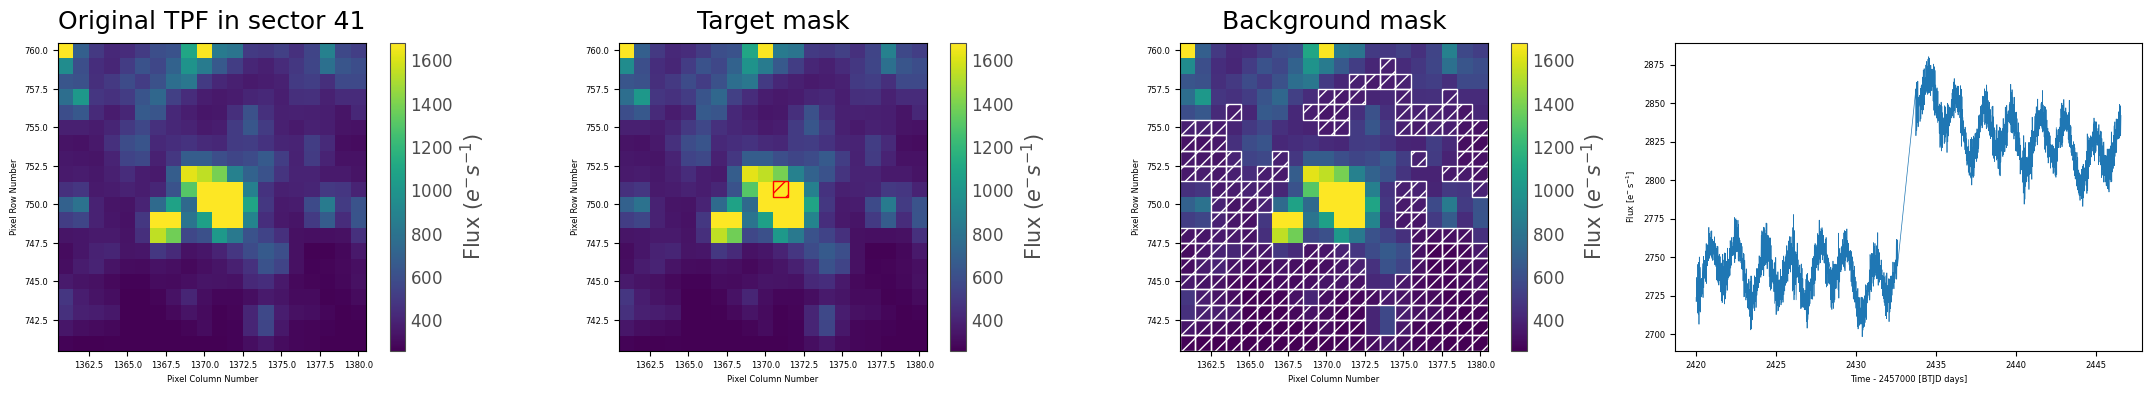

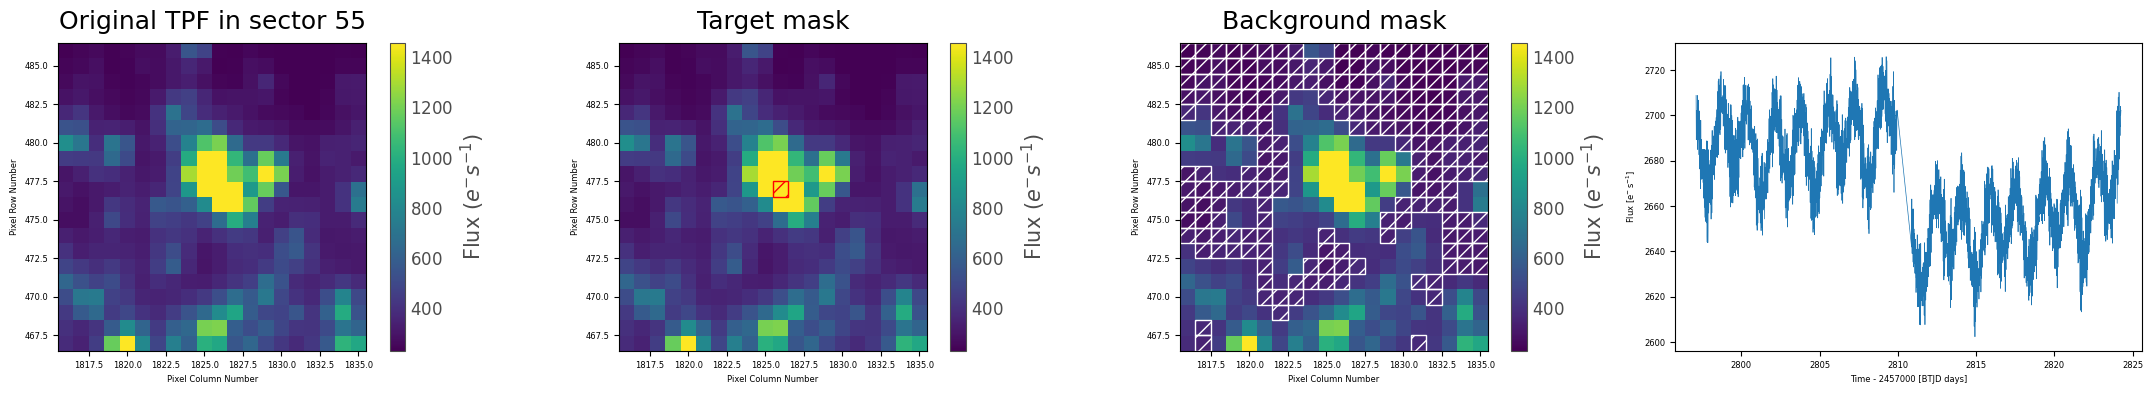

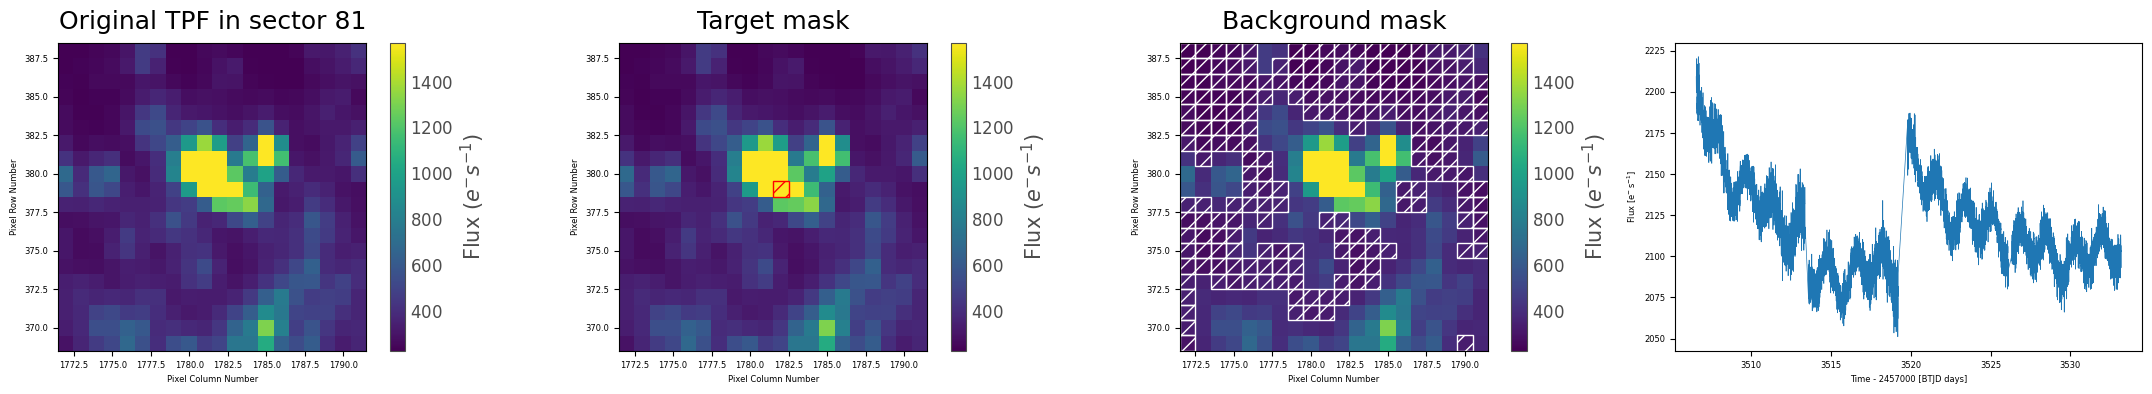

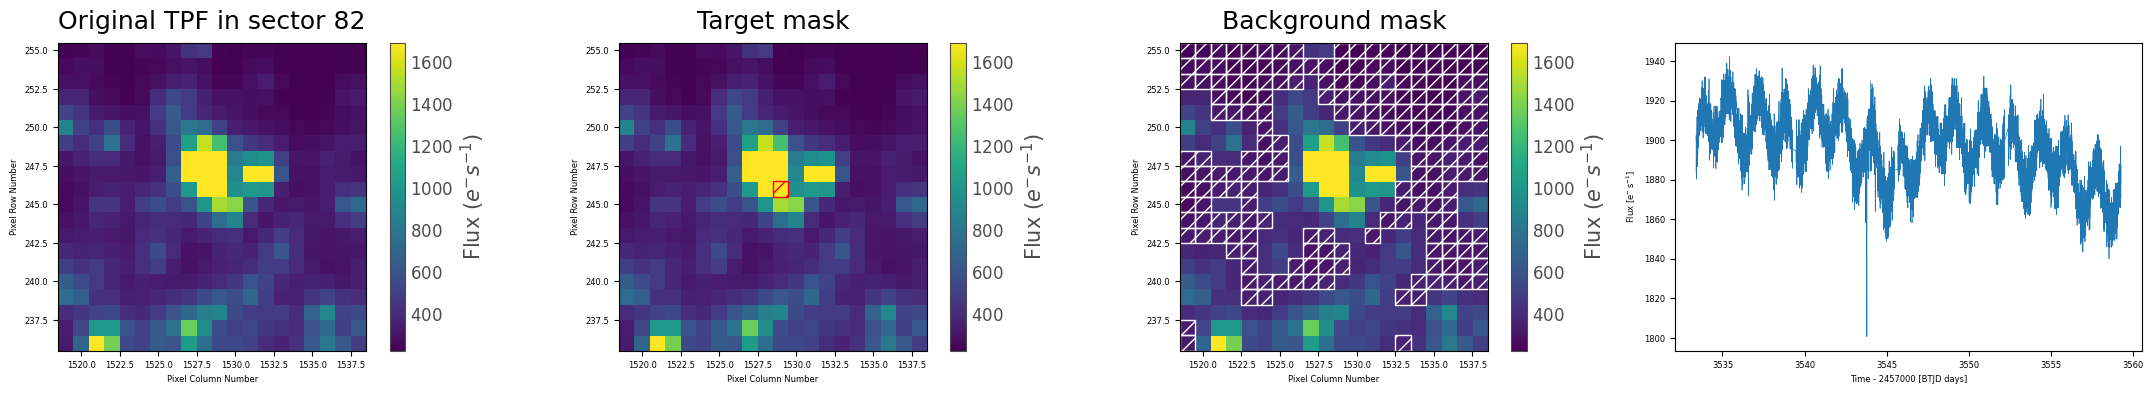

In [ ]:
observations = []

for tpf in tpfs:
  photometry = photometry_func(tpf, mask_radius = 0, mask_size= 3, threshold_include = 200, mask_type= 1, reference_pixel= "center")

  if not (os.path.exists(create_path("sector_", str(photometry[0].lc.sector))) and os.path.isdir(create_path("sector_", str(photometry[0].lc.sector)))):
    create_subfolder(your_name, "sector_" + str(photometry[0].lc.sector))

  observations.append(photometry[0])
  if not photometry[1]:
    print("Average flux did not pass the treshold, consider removing sector" + str(photometry[0].lc.sector))

observations_backup = observations.copy()

You may save all of the lightcurves before amending them.

In [ ]:
for obs in observations:
  fig, axes = plt.subplots(1, 1, figsize=(4, 4))
  axes.set_title("Light curve in sector " + str(obs.lc.sector), fontdict= {'fontsize': 10})
  obs.lc.plot(ax = axes)
  plt.savefig(create_sector_folder_path(str(obs.lc.sector),your_name + "_lc_sector_" + str(obs.lc.sector), ".png"), bbox_inches='tight')


You may save a txt file compatible with SILICUPS.

In [ ]:
for obs in observations:
  create_lc_txt(obs.normlc.time, obs.normlc.flux, obs.normlc.flux_err, create_sector_folder_path(str(obs.lc.sector),your_name + "_lc_sector_" + str(obs.lc.sector), ".txt"))

You may reset the observations, if you accidentaly remove sectors you didnt mean to remove.

In [ ]:
observations = observations_backup.copy()
for obs in observations:
  print(obs.lc.sector)

You may exculde some observations.

In [ ]:
observations = exclude_observations(observations)
for obs in observations:
  print(obs.lc.sector)



---

# Splitting a light curve

You may split an observation in the middle and detrend the newly created lightcurves.

Input all of the sectors you wish to split and detrend separated by a comma: 41,55,81,82


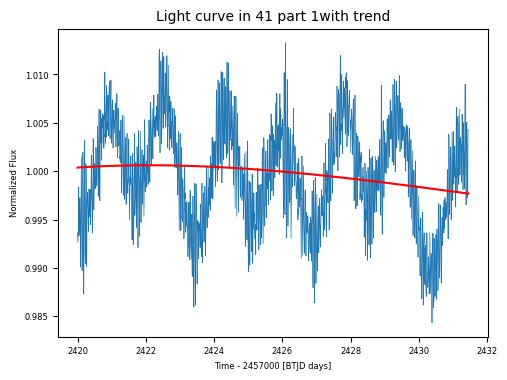

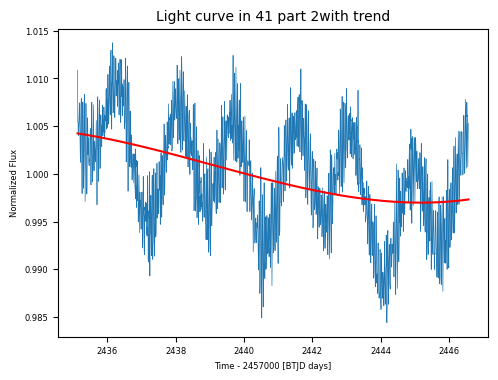

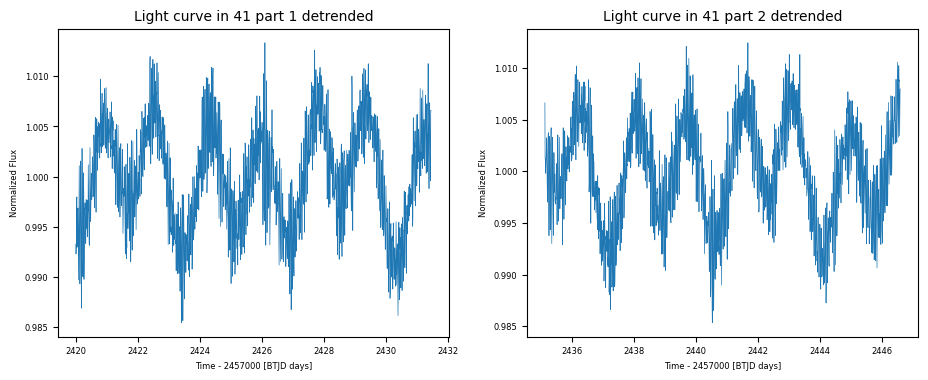

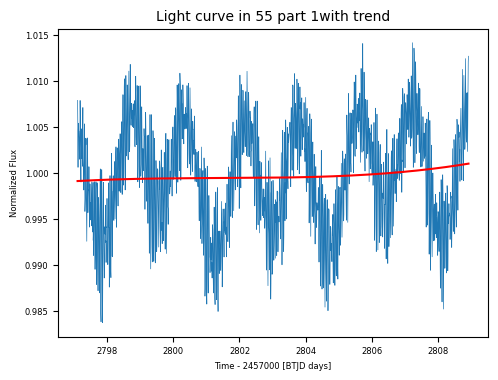

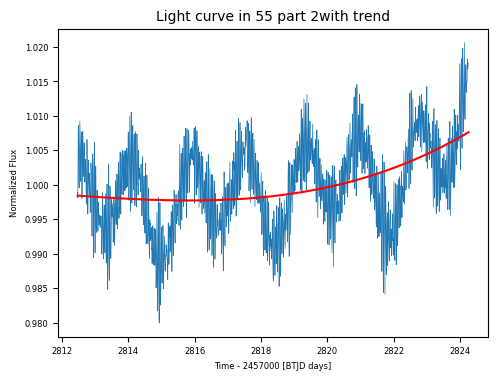

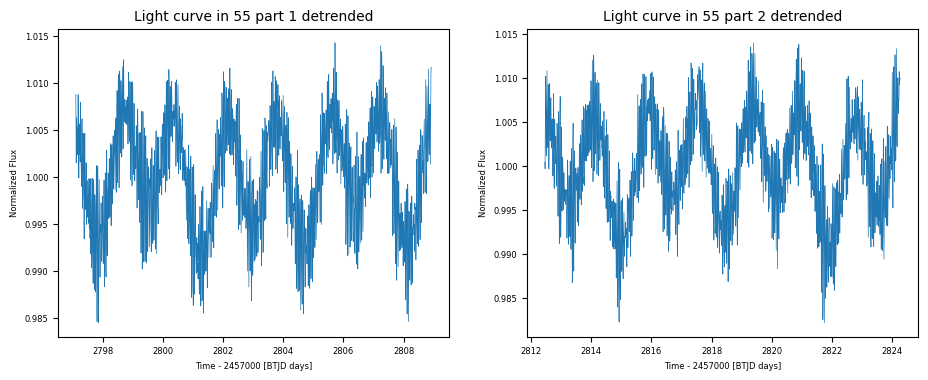

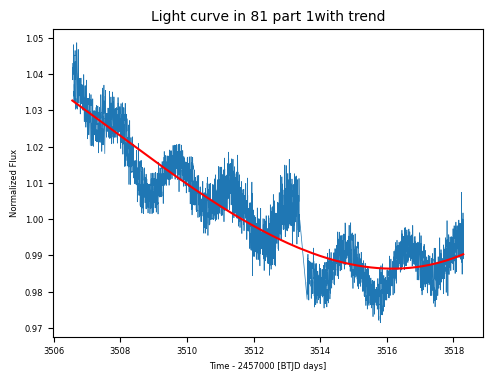

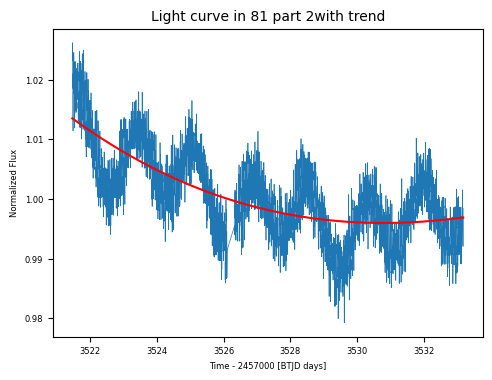

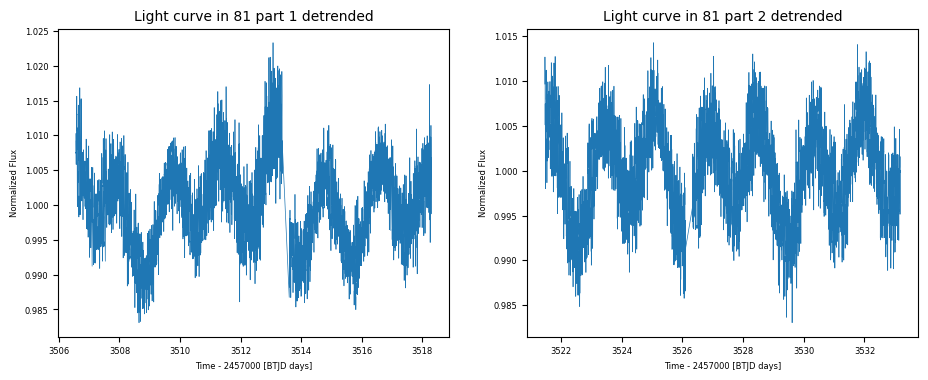

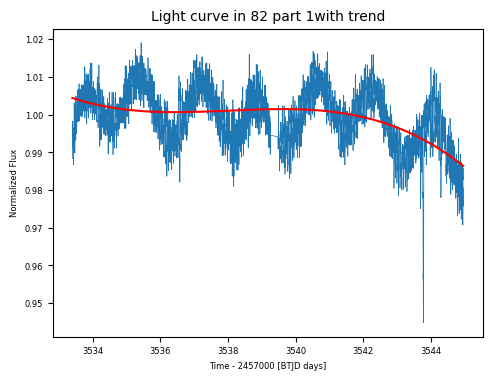

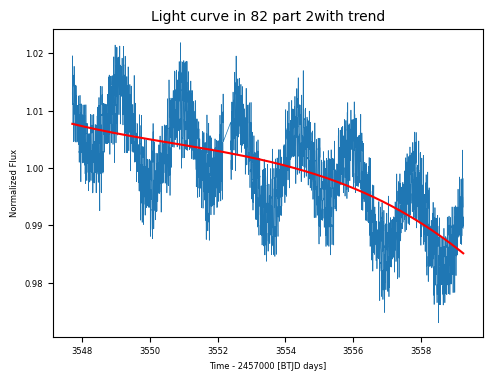

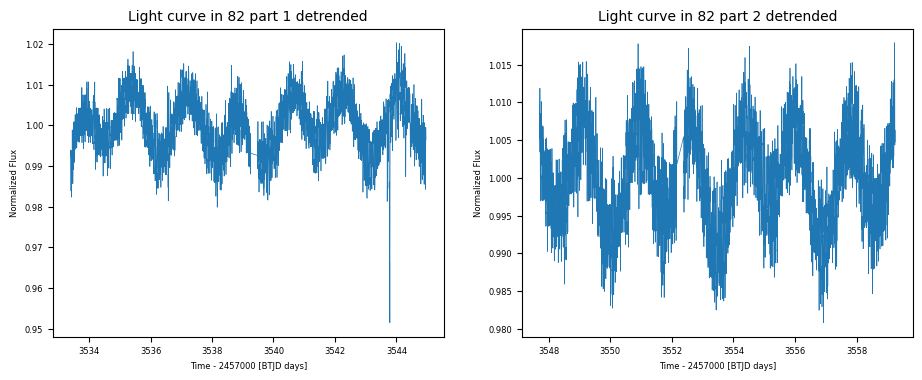

In [ ]:
split_lc = split_and_detrend_observation(observations, degree = 3) #returns a list of lists containing the parts of sectors detrended lightcurves

Optional code to remove outliers in a specific LC.

In [ ]:
split_lc[3][0] = split_lc[3][0].remove_outliers(sigma = 3)

Finding an ephemeris for an EB.

First refine the truncation, so it only includes the primary minimum.
You may choose whichever sector and part of lightcurve.

In [ ]:
for lc in split_lc:
    print("the sector " + str(lc[0].sector)+" has the index " + str(split_lc.index(lc)))

In [ ]:
sector_index = 0
part_index = 1

In [ ]:
split_lc[sector_index][part_index].scatter()

In [ ]:
truncated_split_lc = split_lc[sector_index][part_index].truncate(before = 2407.06, after = 2407.22)
truncated_split_lc.scatter()

This function will fit the lc above with a parabola and output the minimum.

In [ ]:
eclipse_time = fit_eclipse(truncated_split_lc)
print(eclipse_time)

You may check that the minimum lines up.

In [ ]:
split_lc[sector_index][part_index].fold(period = split_lc[sector_index][part_index].to_periodogram(method = "bls", minimum_period = minimum_period, maximum_period= maximum_period).period_at_max_power, epoch_time=eclipse_time, normalize_phase = True).scatter()

You may normalize the amplitudes of the lcs.

In [ ]:
for lc in split_lc:
  for part in lc:
    print("Sector " + str(part.sector))
    split_lc[split_lc.index(lc)][lc.index(part)] = normalize_amplitude_percentile(lc = part)

Next we will create a single lightcurve from the detrended light curves

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

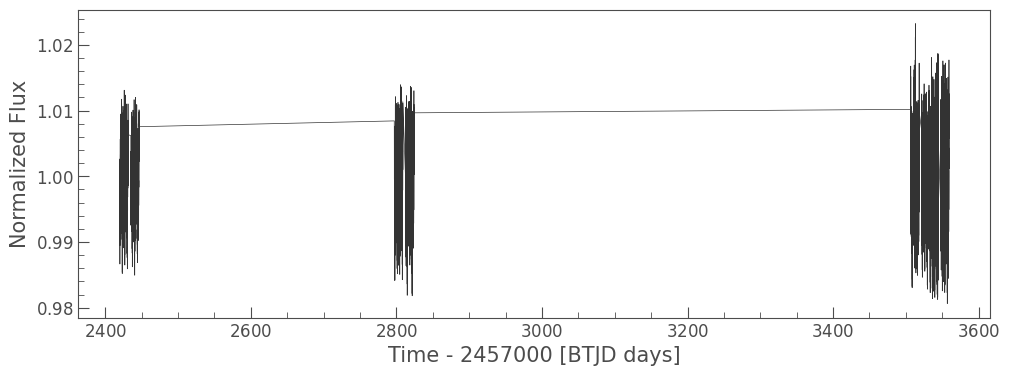

In [ ]:
split_lc_collection = lk.LightCurveCollection([])

for lc in split_lc:
  for part in lc:
    split_lc_collection.append(part) #you may use the function normalize_amplitude_percentile here

split_main_lc = split_lc_collection.stitch() #creates a single normalized lightcurve from the whole collection(normalized to the median of the lc)
split_main_lc.plot()

You may create a compressed time series of the main LC.

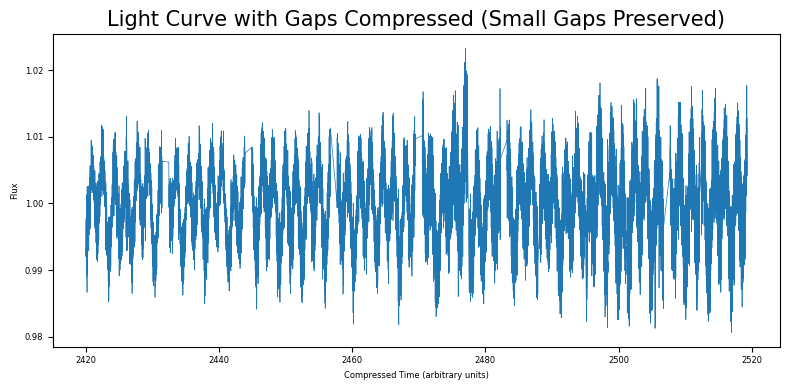

In [ ]:
create_compressed_time_series(split_main_lc)

Create a weighted average of pariods from the sectors.

In [ ]:
split_periods = []
split_weights = []

for lc in split_lc:
  for part in lc:
    split_weights.append(math.sqrt(len(part.flux)))
    find_period_and_plot_folded_lightcurve(part, lc.index(part), pg_type = "bls")

In [ ]:
np.average(split_periods, weights = split_weights)

Quick change for min and max period.

In [ ]:
minimum_period = 0.01
maximum_period = 1

Plotting phased sector lcs.

The periodogram for the lc provided has a period determined by the LS method of 0.04310425750579506 d


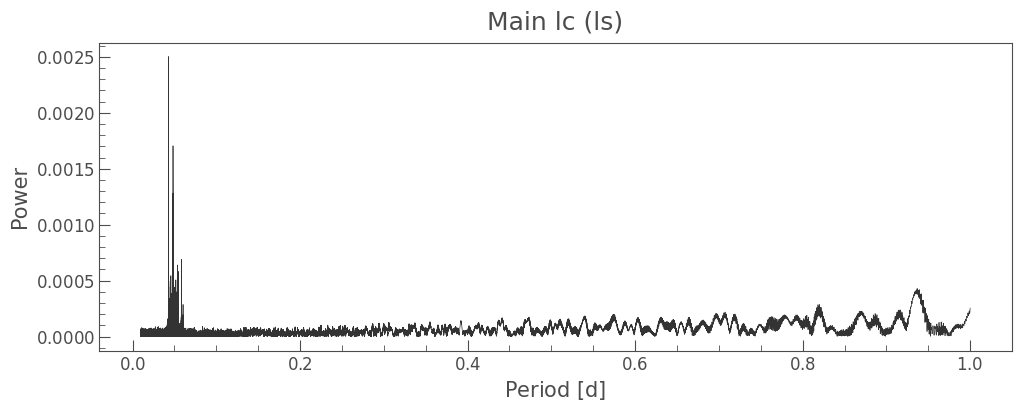

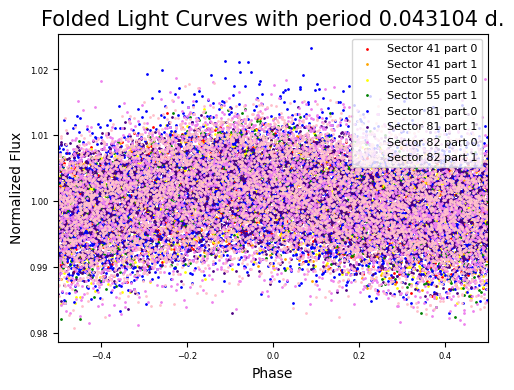

In [ ]:
split_main_period = plot_folded_split_lightcurve(split_lc, pg_type= "ls", user_comment="main_period", epoch_time = 0.2, move_phase = 0)



---

# Output

Will create txt file with important info, possibly will save csv for every sector reduced.

In [ ]:
create_files(observations, to_bool(input('Do you want to save csv files of the light curve data for each sector? (y/n)'))) #creates a text file with the information

Will save the files into a .zip file and download it.

In [ ]:
zip_and_download_folder(your_name)

Will delete the .zip file.

In [ ]:
delete_zip_file(your_name + ".zip")

Will delete folder.

In [ ]:
shutil.rmtree(your_name)

---







---

# Lightcurves for non split LCs - Pretty much outdated.



Now we have a list of observations, where each item has a lightcurve file as .lc and a periodogram as .pg and a normalized lightcurve as .normlc and the period at max power as .period and a flattened lightcurve as .flatlc

The next cell will plot all of the sub light curves and then create one normalized main lightcurve and plot it as well

You may plot the flattened and detrended lightcurves to see whether it might be beneficial to use them

In [ ]:
for obs in observations:
  obs.flatlc.plot(title = "Flattened lightcurve in sector " + str(obs.lc.sector))

In [ ]:
for obs in observations:
  obs.detrended_lc = detrend_lc(obs.lc, degree = 3, part = None)
  obs.detrended_lc.plot(title = "Detrended lightcurve in sector " + str(obs.lc.sector))

Now we will plot all of the normalized lightcurves and add them to a lc collection and create one main lightcurve. Feel free to change them to the flattened lightcurves. You shouldnt use this, if you split some sectors.

In [ ]:
main_lc = plot_normalized_lightcurves(observations)

In [ ]:
flat_main_lc = plot_flattened_lightcurves(observations) #experimental

In [ ]:
for obs in observations:
  obs.normlc.scatter(title = "Normalized lightcurve in sector " + str(obs.lc.sector))



---
# Periods for batch - Pretty much outdated

Now we will analyse the periods of the observations. We will print the most likely periods of each observation based on the normalized curve as well as the most likely period for the main normalized lightcurve. We will also plot the power of the periods for all of the observations and for the main lightcurve.

Now we have an observation object, it has a lightcurve file as .lc and a normalized lightcurve as .normlc.

You may choose what type of periodogram will be used.

In [ ]:
#Uses LombScargle
for obs in observations:
  obs.periodogram = obs.normlc.to_periodogram(method = "ls", minimum_period = minimum_period, maximum_period= maximum_period, oversample_factor = oversample_factor) #creates the periodogram of a normalized lc
  obs.period = obs.periodogram.period_at_max_power
  obs.periodogram_type = "ls"

In [ ]:
#Uses BoxLeastSquares
for obs in observations:
  obs.periodogram = obs.normlc.to_periodogram(method = "bls", minimum_period = minimum_period, maximum_period= maximum_period) #creates the periodogram of a normalized lc
  obs.period = obs.periodogram.period_at_max_power
  obs.periodogram_type = "bls"

In [ ]:
main_periodogram = print_and_save_norm_LS_periodograms(observations, pg_type="bls")

Flat lcs

In [ ]:
#Uses LombScargle
for obs in observations:
  obs.periodogram = obs.flatlc.to_periodogram(method = "ls", minimum_period = minimum_period, maximum_period= maximum_period, oversample_factor = oversample_factor) #creates the periodogram of a normalized lc
  obs.period = obs.periodogram.period_at_max_power

In [ ]:
#Uses BoxLeastSquares
for obs in observations:
  obs.periodogram = obs.flatlc.to_periodogram(method = "bls", minimum_period = minimum_period, maximum_period= maximum_period) #creates the periodogram of a normalized lc
  obs.period = obs.periodogram.period_at_max_power

In [ ]:
flat_main_periodogram = print_and_save_flat_LS_periodograms(observations) #experimental

**You may print each sector folded with its period.**

In [ ]:
for obs in observations:
  fig, axes = plt.subplots(1, 1, figsize=(5, 4))
  obs.normlc.fold(period=obs.period, epoch_time=2, normalize_phase=True).scatter(c="xkcd:sky blue", ax=axes, label="Sector "+str(obs.lc.sector))
  plt.savefig(create_sector_folder_path(str(obs.lc.sector),your_name + "_sector_"+ str(obs.lc.sector)+ "_folded_lc", ".png"), bbox_inches='tight')
  plt.show()

Weighted average of periods

In [ ]:
weighted_average_period(observations)

Now we will plot the lightcurves folded with the period of the main light curve. The epoch_time argument aligns the curves to be roughly the same. And save the graph to the respective folder.

In [ ]:
plot_folded_lightcurve_with_sine(observations) #plots the folded lightcurves with the sine wave

#main_lc.fold(period=main_periodogram.period_at_max_power, normalize_phase= True, epoch_time= 0).scatter(c = "black") #plots the folded lightcurve for the main lc


In [ ]:
plot_folded_lightcurve(observations, user_period = 8.50262078) #plots the folded lightcurves with the sine wave

#




---

# **Single sector photometry (mainly for testing) - OUTDATED**

For testing purposes, you may chose a single sector where you would like to perform the photometry and you may adjust the parameters for the photometry.

In [ ]:
sector = input("sector: ") # input
filtered_search_results = search_results[search_results.table['mission'] == "TESS Sector "+sector] # Access sector using table
filtered_search_results

In [ ]:
tpf = filtered_search_results.download(cutout_size=30,quality_bitmask=quality_bitmask) #downloads the cutouts into a TargetPixelFile using the set parameters

We will now perform photometry on the tpf, you will be prompted with multiple questions.

In [ ]:
photometry = photometry_func(tpf, mask_radius = 0, cutout_size = 30)

observations = []

if photometry[1]:
  observations.append(photometry[0])
else:
  print("The observation data from this sector is not suitable to use for photometry, please choose a different sector (the flux was most likely too low and didnt pass the threshold).")



---

# **TPFs - OUTDATED**

---
This part of the notebook will search the MAST archive for TPFs around the given coordinates and apply a mask, which you can change to the TPFs and create a lightcurve.

LightCurve objects - https://heasarc.gsfc.nasa.gov/docs/tess/LightCurve-object-Tutorial.html

In [ ]:
#You may enter a custom radius for the search
radius = input("Search radius in arcseconds (defult is 0.0001 arcsec):")


In [ ]:
#The lightkurve package will find all of the TPFs for the given radius around the given coordinates.
search = lk.search_targetpixelfile(coord, radius = radius)
#A simple table of the results will be printed
search

In [ ]:
#A not so simple table of the results will be printed
search.table



Using this website https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html

you may visually check whether the target_name in the detailed table above corresponds with the star you want. You do, however, need to search the MAST catalog by using "TIC target_name".

After you have done this, and the search came back with results with multiple target_name, you may filter the search to only include the TICs you want



In [ ]:
wanted_tic = input("Copy the TIC of the wanted star here:")
filtered_search = search[search.target_name == wanted_tic]
filtered_search

In [ ]:
filtered_search[0]

We will now download all of the TPFs into a collection. You may change the filter in the cell above to narrow the search, I very much recommend checking the size of the files before downloading them.

In [ ]:
TPF = filtered_search[0].download()

In [ ]:
TPF.plot()

In [ ]:
lc = TPF_collection.to_lightcurve(aperture_mask=TPF_collection.pipeline_mask)
lc

In [ ]:
lc.sector


In [ ]:
lc.flux, lc.time

In [ ]:
lc.plot()




---

# **LCFs - OUTDATED**

---


LightCurveFile Objects - https://heasarc.gsfc.nasa.gov/docs/tess/LightCurveFile-Object-Tutorial.html

In [ ]:
search_result = lk.search_lightcurve(coord)
search_result

In [ ]:
lcf = lk.search_lightcurve(coord, sector=75).download()
lcf

In [ ]:
lcf.plot()

In [ ]:
ax = lcf.plot(label='PDCSAP Flux', normalize=True)
lcf.plot(column='sap_flux', normalize=True, label='SAP Flux', ax=ax);

In [ ]:
lcf.meta["RA_OBJ"]
lcf.meta

In [ ]:
# Get the current working directory
current_dir = os.getcwd()

# Define the subfolder name (replace 'subfolder' with your desired folder name)
subfolder = "Lightcurves"

# Create the subfolder path
subfolder_path = os.path.join(current_dir, subfolder)

# Ensure the subfolder exists; if not, create it
if not os.path.exists(subfolder_path):
  os.makedirs(subfolder_path)

# Check if the folder exists
if os.path.exists(subfolder_path):
# Loop through all files and subdirectories in the folder
  for filename in os.listdir(subfolder_path):
    file_path = os.path.join(subfolder_path, filename)
# If it's a file, delete it
    os.remove(file_path)
  print(f"Folder {subfolder_path} has been emptied.")
else:
  print(f"Folder {subfolder_path} does not exist.")

file_path = os.path.join(subfolder_path, "text" + ".csv")

lcf.to_csv(file_path)

In [ ]:
lcf.to_pandas()

In [ ]:
perioda = lk.periodogram.LombScarglePeriodogram.from_lightcurve(lcf,minimum_period = 1.5, maximum_period= 3, oversample_factor = 10)

In [ ]:
perioda.period_at_max_power

In [ ]:
perioda.plot()